<a href="https://colab.research.google.com/github/ayoubkourikchi-bit/data-projects/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import plot_tree

In [ ]:
df = pd.read_csv('/content/instagram_users_lifestyle2.csv')

In [ ]:
df.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51.0,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0.0,Free,7.83
1,2,Instagram,64.0,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3.0,Free,1.43
2,3,Instagram,41.0,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1.0,Free,9.67
3,4,Instagram,27.0,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1.0,Free,0.94
4,5,Instagram,55.0,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0.0,Free,1.03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440371 entries, 0 to 440370
Data columns (total 58 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   user_id                         440371 non-null  int64  
 1   app_name                        440370 non-null  object 
 2   age                             440370 non-null  float64
 3   gender                          440370 non-null  object 
 4   country                         440370 non-null  object 
 5   urban_rural                     440370 non-null  object 
 6   income_level                    440370 non-null  object 
 7   employment_status               440370 non-null  object 
 8   education_level                 440370 non-null  object 
 9   relationship_status             440370 non-null  object 
 10  has_children                    440370 non-null  object 
 11  exercise_hours_per_week         440370 non-null  float64
 12  sleep_hours_per_

In [ ]:
df.isna().sum()

,0
user_id,0
app_name,1
age,1
gender,1
country,1
urban_rural,1
income_level,1
employment_status,1
education_level,1
relationship_status,1


In [ ]:
df = df.dropna()

In [ ]:
Users_Country = df.groupby("country")['user_id'].nunique().sort_values(ascending=False).reset_index(name='unique_user_count')
Users_Country

,country,unique_user_count
0,United States,110041
1,India,79290
2,Brazil,52849
3,United Kingdom,34987
4,Canada,30700
5,Australia,26484
6,South Korea,22214
7,Germany,22066
8,Japan,17803


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'United States'),
  Text(1, 0, 'India'),
  Text(2, 0, 'Brazil'),
  Text(3, 0, 'Other'),
  Text(4, 0, 'United Kingdom'),
  Text(5, 0, 'Canada'),
  Text(6, 0, 'Australia'),
  Text(7, 0, 'South Korea'),
  Text(8, 0, 'Germany'),
  Text(9, 0, 'Japan')])

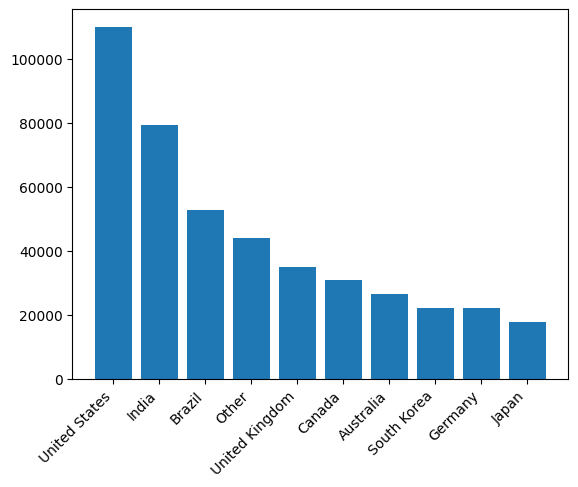

In [ ]:
plt.bar(Users_Country["country"], Users_Country['unique_user_count'])
plt.xticks(rotation=45, ha='right')

In [ ]:
df = df[df["country"] != "Other"]

In [ ]:
object_cols = df.select_dtypes(include = 'object').columns
print(object_cols)

Index(['app_name', 'gender', 'country', 'urban_rural', 'income_level',
       'employment_status', 'education_level', 'relationship_status',
       'has_children', 'diet_quality', 'smoking', 'alcohol_frequency',
       'uses_premium_features', 'last_login_date', 'content_type_preference',
       'preferred_content_theme', 'privacy_setting_level',
       'two_factor_auth_enabled', 'biometric_login_used',
       'subscription_status'],
      dtype='object')


In [ ]:
summary = pd.DataFrame({
    'Column': object_cols,
    'Unique Values': [df[col].nunique() for col in object_cols]
})
summary

,Column,Unique Values
0,app_name,1
1,gender,4
2,country,9
3,urban_rural,3
4,income_level,5
5,employment_status,7
6,education_level,9
7,relationship_status,5
8,has_children,2
9,diet_quality,5


In [ ]:
df['education_level'].unique()

array(['Bachelor’s', 'Other', 'Master’s', 'High school', 'Some college',
       'Secondary', 'PhD', 'High School', 'Bachelor'], dtype=object)

In [ ]:
df['gender'].unique()

array(['Female', 'Non-binary', 'Male', 'Prefer not to say'], dtype=object)

In [ ]:
df['urban_rural'].unique()

array(['Rural', 'Urban', 'Suburban'], dtype=object)

In [ ]:

df['income_level'].unique()

array(['High', 'Middle', 'Upper-middle', 'Lower-middle', 'Low'],
      dtype=object)

In [ ]:

df['employment_status'].unique()

array(['Retired', 'Full-time employed', 'Student', 'Unemployed',
       'Freelancer', 'Not employed', 'Part-time'], dtype=object)

In [ ]:
df['diet_quality'].unique()

array(['Good', 'Very poor', 'Poor', 'Average', 'Excellent'], dtype=object)

In [ ]:

df['smoking'].unique()

array(['No', 'Yes', 'Former'], dtype=object)

In [ ]:

df['alcohol_frequency'].unique()

array(['Rarely', 'Never', 'Several times a week', 'Weekly', 'Daily'],
      dtype=object)

In [ ]:

df['content_type_preference'].unique()

array(['Mixed', 'Photos', 'Stories', 'Videos', 'Reels', 'Live'],
      dtype=object)

In [ ]:

df['preferred_content_theme'].unique()

array(['Tech', 'Fashion', 'Other', 'Food', 'Travel', 'Art', 'Music',
       'Fitness'], dtype=object)

In [ ]:

df['relationship_status'].unique()

array(['Single', 'Divorced', 'In a relationship', 'Married', 'Widowed'],
      dtype=object)

In [ ]:
numeric_cols = df.select_dtypes(include = ['int64', 'float64']).columns
country_means = (
    df.groupby('country')[numeric_cols].mean().round(2)
)
country_means = country_means.drop(columns = 'user_id')
pd.set_option('display.max_columns', None)
country_means

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,hobbies_count,social_events_per_month,books_read_per_year,volunteer_hours_per_month,travel_frequency_per_year,daily_active_minutes_instagram,sessions_per_day,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,linked_accounts_count,user_engagement_score
country,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Australia,39.01,7.19,7.01,19.99,5.48,25.00,124.72,79.49,8000.04,36.25,3.00,4.02,9.99,3.99,3.00,188.77,10.39,5.93,175.85,101.36,119.39,34.33,28.81,30.65,20.13,4.76,94.45,37.77,33.04,56.69,2166.23,2600.98,0.5,2018.43,20.49,1.98,1.63
Brazil,38.94,7.13,7.00,19.98,5.49,24.99,124.36,79.52,8000.16,36.21,3.00,3.99,10.00,4.00,3.00,188.12,10.33,5.96,175.69,101.14,119.08,34.22,28.82,30.55,20.02,4.77,94.02,37.52,32.93,56.50,2164.81,2602.07,0.5,2018.50,20.50,1.97,1.64
Canada,39.03,7.14,7.00,19.99,5.49,25.00,124.43,79.58,8000.57,36.21,3.00,4.00,9.99,4.00,3.01,188.46,10.30,5.99,175.57,101.22,119.29,34.24,28.81,30.62,20.10,4.77,94.14,37.63,33.04,56.62,2173.00,2609.15,0.5,2018.50,20.54,1.97,1.65
Germany,39.04,7.09,6.99,20.03,5.51,24.98,124.57,79.41,8000.12,36.13,3.00,4.00,10.01,4.01,3.01,188.26,10.31,5.94,175.52,101.23,119.00,34.22,28.85,30.56,20.10,4.78,94.10,37.65,32.93,56.40,2163.33,2592.87,0.5,2018.47,20.51,1.98,1.64
India,39.02,7.14,7.00,20.02,5.48,25.00,124.58,79.50,8000.03,36.15,2.99,3.99,10.00,4.00,2.99,188.85,10.36,5.98,175.92,101.35,119.42,34.31,28.84,30.67,20.11,4.79,94.49,37.67,33.04,56.68,2149.62,2598.88,0.5,2018.48,20.54,1.97,1.64
Japan,38.87,7.12,7.01,20.15,5.50,25.04,124.63,79.55,7999.70,36.29,2.99,4.00,10.03,4.00,3.01,189.55,10.37,5.96,176.40,101.62,119.76,34.39,28.97,30.73,20.14,4.79,94.76,37.96,33.18,56.78,2150.90,2593.38,0.5,2018.49,20.53,1.98,1.62
South Korea,39.06,7.12,7.02,19.91,5.48,24.96,124.42,79.40,8000.26,36.11,2.99,3.99,10.00,3.97,3.00,187.84,10.26,5.98,175.31,101.06,118.92,34.13,28.80,30.56,20.04,4.75,93.84,37.66,32.83,56.45,2148.17,2610.30,0.5,2018.44,20.55,1.97,1.66
United Kingdom,38.91,7.16,7.00,20.09,5.47,24.97,124.38,79.46,8000.25,36.22,2.98,4.00,10.01,4.00,2.98,189.65,10.42,5.98,176.48,101.65,119.77,34.45,29.02,30.72,20.17,4.79,94.88,37.98,33.25,56.94,2159.24,2615.87,0.5,2018.49,20.53,1.98,1.63
United States,38.97,7.14,6.99,20.00,5.50,25.00,124.50,79.54,8000.45,36.21,3.00,3.99,9.99,4.00,3.00,188.24,10.34,5.97,175.61,101.14,119.12,34.21,28.82,30.59,20.07,4.76,94.09,37.67,32.98,56.49,2151.11,2599.39,0.5,2018.45,20.52,1.98,1.64


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

country_std = (
    df.groupby('country')[numeric_cols]
      .std()
      .round(2)
      .drop(columns='user_id', errors='ignore')
      .reset_index()
)

pd.set_option('display.max_columns', None)
country_std

,country,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,hobbies_count,social_events_per_month,books_read_per_year,volunteer_hours_per_month,travel_frequency_per_year,daily_active_minutes_instagram,sessions_per_day,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,linked_accounts_count,user_engagement_score
0,Australia,15.27,3.97,1.10,11.79,2.87,3.99,20.21,11.49,88.23,14.96,1.74,2.00,3.17,2.41,1.73,109.66,7.92,3.88,75.99,38.66,55.87,17.42,12.21,14.27,9.83,3.08,56.28,25.32,21.37,35.30,3540.06,2745.78,0.29,4.62,8.65,1.35,1.78
1,Brazil,15.29,3.98,1.10,11.82,2.87,3.97,20.21,11.55,89.32,15.14,1.74,2.00,3.16,2.41,1.74,109.96,7.91,3.88,76.01,38.74,56.08,17.46,12.21,14.27,9.81,3.11,56.37,25.32,21.45,35.30,3343.09,2753.60,0.29,4.61,8.66,1.35,1.80
2,Canada,15.33,3.99,1.09,11.84,2.86,3.97,20.22,11.54,89.34,15.23,1.73,2.00,3.14,2.42,1.74,110.50,7.88,3.89,76.51,38.86,56.30,17.54,12.24,14.39,9.87,3.11,56.58,25.45,21.61,35.60,3443.51,2757.88,0.29,4.62,8.70,1.34,1.82
3,Germany,15.25,3.99,1.09,11.82,2.88,3.98,20.20,11.53,89.41,15.01,1.73,2.00,3.18,2.42,1.72,110.12,7.89,3.86,76.07,38.81,55.99,17.52,12.28,14.35,9.88,3.14,56.49,25.43,21.40,35.30,3644.10,2737.27,0.29,4.61,8.68,1.36,1.82
4,India,15.32,3.99,1.10,11.81,2.87,3.99,20.23,11.55,89.46,15.14,1.73,1.99,3.17,2.42,1.73,110.06,7.94,3.88,76.25,38.74,56.11,17.46,12.26,14.33,9.89,3.11,56.51,25.30,21.44,35.35,3360.59,2749.13,0.29,4.62,8.70,1.36,1.80
5,Japan,15.28,4.00,1.11,11.83,2.88,3.96,20.28,11.55,89.69,15.08,1.73,2.00,3.14,2.41,1.74,110.13,7.88,3.86,75.99,38.66,56.22,17.49,12.25,14.33,9.84,3.12,56.52,25.42,21.60,35.28,3407.35,2732.62,0.29,4.60,8.66,1.35,1.76
6,South Korea,15.31,3.98,1.10,11.79,2.88,3.98,20.20,11.52,89.08,15.05,1.72,2.00,3.14,2.39,1.72,110.43,7.91,3.89,76.81,38.96,56.24,17.51,12.27,14.36,9.91,3.09,56.49,25.48,21.44,35.51,3230.88,2759.14,0.29,4.60,8.69,1.35,1.83
7,United Kingdom,15.25,4.00,1.10,11.84,2.87,3.98,20.18,11.54,89.18,15.04,1.73,1.99,3.15,2.41,1.72,110.10,8.00,3.88,76.08,38.71,56.19,17.44,12.24,14.36,9.92,3.11,56.51,25.42,21.48,35.36,3291.30,2755.08,0.29,4.59,8.69,1.35,1.79
8,United States,15.28,3.99,1.10,11.85,2.86,3.98,20.22,11.54,89.16,15.09,1.73,2.00,3.15,2.42,1.73,110.24,7.97,3.90,76.18,38.79,56.15,17.50,12.26,14.35,9.90,3.10,56.50,25.41,21.47,35.36,3377.25,2744.15,0.29,4.62,8.70,1.35,1.80


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

country_modes = (df.groupby('country')[categorical_cols]
                 .agg(lambda x: x.mode()[0]))

country_modes

,app_name,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,diet_quality,smoking,alcohol_frequency,uses_premium_features,last_login_date,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,subscription_status
country,,,,,,,,,,,,,,,,,,,,
Australia,Instagram,Male,Australia,Urban,Middle,Full-time employed,Bachelor’s,Single,No,Average,No,Rarely,No,2026-01-01,Videos,Music,Public,Yes,No,Free
Brazil,Instagram,Male,Brazil,Urban,Middle,Full-time employed,Bachelor’s,Single,No,Average,No,Rarely,No,2025-10-24,Reels,Fitness,Friends only,Yes,No,Free
Canada,Instagram,Female,Canada,Urban,Middle,Full-time employed,Bachelor’s,Single,No,Average,No,Rarely,No,2025-10-06,Reels,Fashion,Private,Yes,No,Free
Germany,Instagram,Male,Germany,Urban,Middle,Full-time employed,Bachelor’s,Single,No,Average,No,Rarely,No,2025-12-25,Live,Other,Friends only,Yes,No,Free
India,Instagram,Female,India,Urban,Middle,Full-time employed,Bachelor’s,Single,No,Average,No,Rarely,No,2025-05-27,Mixed,Fitness,Friends only,Yes,No,Free
Japan,Instagram,Male,Japan,Urban,Middle,Full-time employed,Bachelor’s,Single,No,Average,No,Rarely,No,2025-02-01,Videos,Fitness,Friends only,Yes,No,Free
South Korea,Instagram,Female,South Korea,Urban,Middle,Full-time employed,Bachelor’s,Single,No,Average,No,Rarely,No,2025-10-27,Mixed,Other,Friends only,Yes,No,Free
United Kingdom,Instagram,Female,United Kingdom,Urban,Middle,Full-time employed,Bachelor’s,Single,No,Average,No,Rarely,No,2025-07-18,Stories,Fashion,Friends only,Yes,No,Free
United States,Instagram,Female,United States,Urban,Middle,Full-time employed,Bachelor’s,Single,No,Average,No,Rarely,No,2025-10-06,Mixed,Music,Public,Yes,No,Free


In [ ]:
# columns where not all countries share the same mode

cols_with_diff_modes = [
    c for c in country_modes.columns
    if country_modes[c].nunique(dropna=True) > 1
]
cols_with_diff_modes

['gender',
 'country',
 'last_login_date',
 'content_type_preference',
 'preferred_content_theme',
 'privacy_setting_level']

In [ ]:
diff_modes_df = pd.DataFrame(cols_with_diff_modes, columns=['variable'])
diff_modes_df

,variable
0,gender
1,country
2,last_login_date
3,content_type_preference
4,preferred_content_theme
5,privacy_setting_level


In [ ]:
df['subscription_status'].unique()

array(['Free', 'Premium', 'Business'], dtype=object)

In [ ]:
df['subscription_status'].value_counts()

,count
subscription_status,
Free,297035
Premium,59774
Business,39625


In [ ]:
pd.crosstab(df['country'], df['subscription_status'])

subscription_status,Business,Free,Premium
country,,,
Australia,2591,19827,4066
Brazil,5173,39594,8082
Canada,3056,22988,4656
Germany,2242,16573,3251
India,7900,59387,12003
Japan,1822,13322,2659
South Korea,2254,16612,3348
United Kingdom,3506,26225,5256
United States,11081,82507,16453


In [ ]:
ct = pd.crosstab(df['country'], df['subscription_status'])

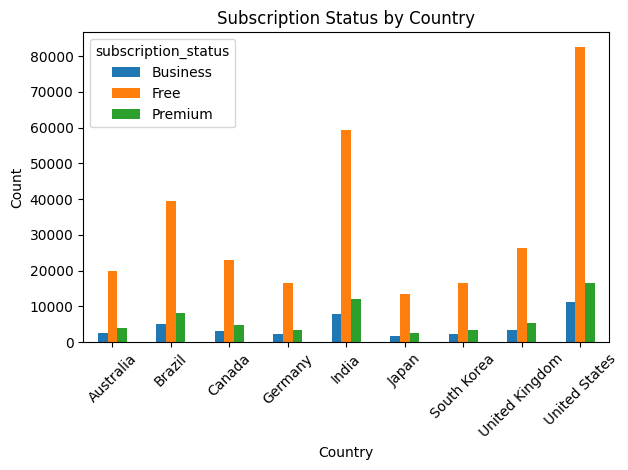

In [ ]:
ct.plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Subscription Status by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

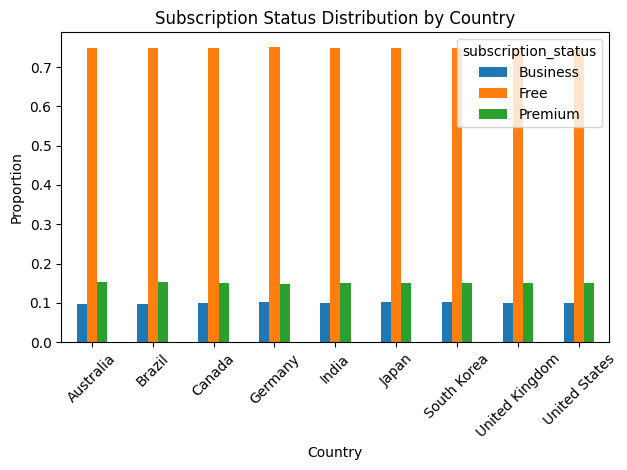

In [ ]:
ct_pct = pd.crosstab(
    df['country'],
    df['subscription_status'],
    normalize='index'
)

ct_pct.plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Proportion')
plt.title('Subscription Status Distribution by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df.groupby('subscription_status')[numeric_cols].mean().round(2)

,user_id,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,hobbies_count,social_events_per_month,books_read_per_year,volunteer_hours_per_month,travel_frequency_per_year,daily_active_minutes_instagram,sessions_per_day,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,average_session_length_minutes,linked_accounts_count,user_engagement_score
subscription_status,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Business,220212.38,38.94,7.13,7.0,19.97,5.49,24.98,124.44,79.51,8000.75,36.22,2.99,4.01,9.99,3.99,2.98,188.18,10.35,5.96,175.63,101.12,119.14,34.21,28.80,30.60,20.05,4.76,94.07,37.64,32.97,56.50,2152.20,2595.51,0.5,2018.48,20.49,1.97,1.65
Free,220215.10,38.97,7.14,7.0,20.03,5.49,25.00,124.50,79.51,8000.17,36.18,3.00,4.00,10.00,4.00,3.00,188.78,10.35,5.97,175.94,101.36,119.37,34.30,28.87,30.64,20.11,4.78,94.37,37.74,33.06,56.67,2160.76,2603.46,0.5,2018.47,20.53,1.98,1.64
Premium,220665.89,39.07,7.15,7.0,19.93,5.48,24.99,124.54,79.48,8000.20,36.23,3.01,3.99,10.00,4.00,3.01,187.73,10.31,5.97,175.11,100.96,118.90,34.14,28.77,30.53,20.02,4.76,93.92,37.49,32.84,56.31,2138.61,2598.66,0.5,2018.45,20.52,1.97,1.65


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# remove the target itself
categorical_cols.remove('subscription_status')

categorical_cols

['app_name',
 'gender',
 'country',
 'urban_rural',
 'income_level',
 'employment_status',
 'education_level',
 'relationship_status',
 'has_children',
 'diet_quality',
 'smoking',
 'alcohol_frequency',
 'uses_premium_features',
 'last_login_date',
 'content_type_preference',
 'preferred_content_theme',
 'privacy_setting_level',
 'two_factor_auth_enabled',
 'biometric_login_used']

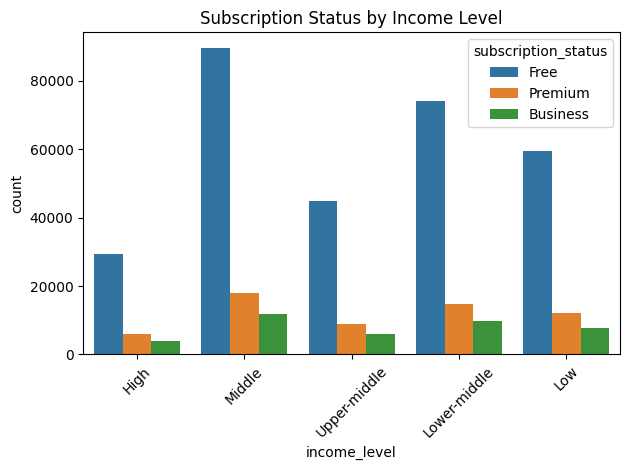

In [ ]:

demographic_vars = [
    'urban_rural',
    'income_level',
    'employment_status',
    'education_level',
    'relationship_status',
    'has_children'
]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.countplot(
    data=df,
    x='income_level',
    hue='subscription_status'
)

plt.title('Subscription Status by Income Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

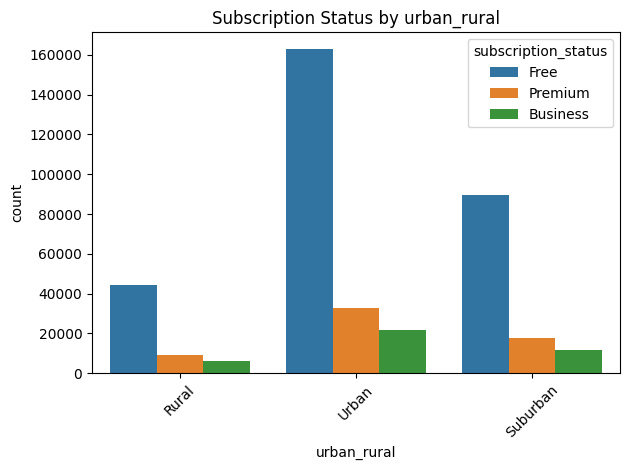

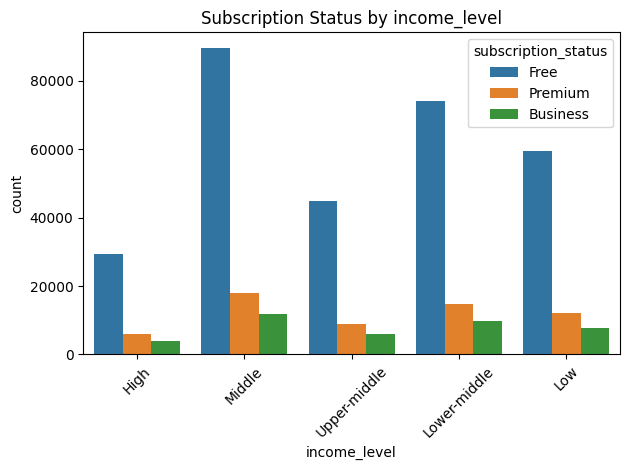

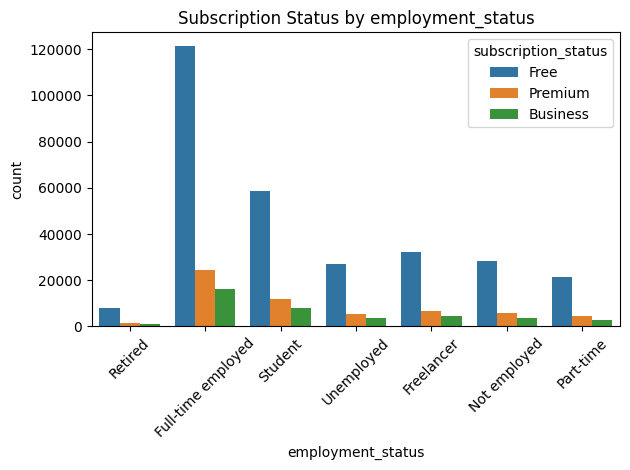

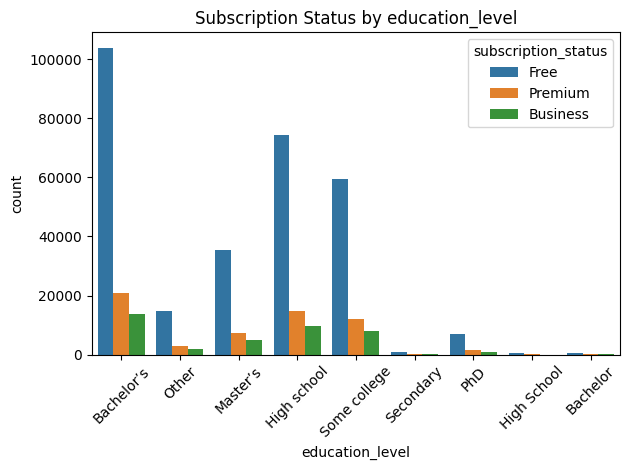

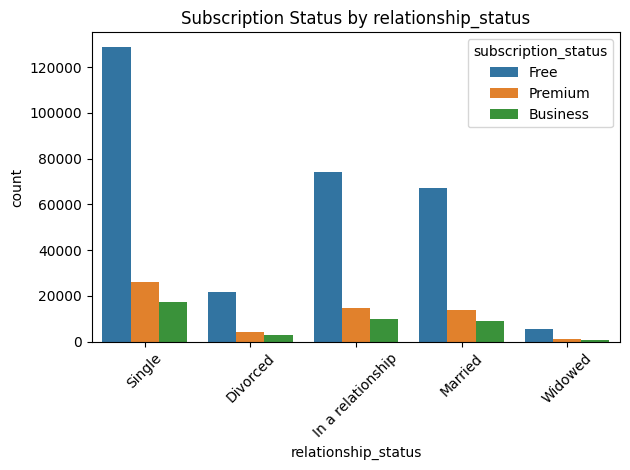

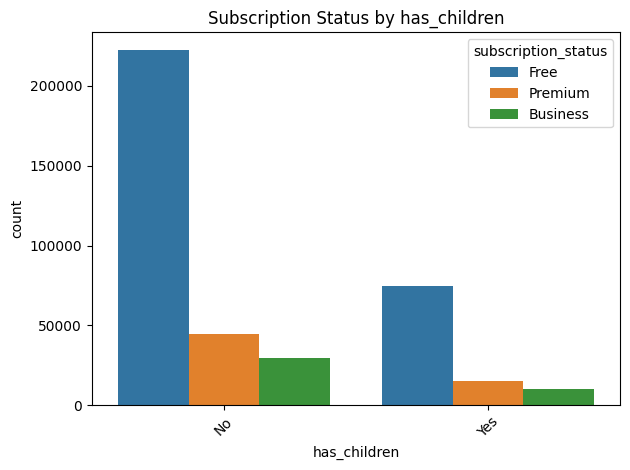

In [ ]:
demographic_vars = [
    'urban_rural',
    'income_level',
    'employment_status',
    'education_level',
    'relationship_status',
    'has_children'
]

for var in demographic_vars:
    plt.figure()

    sns.countplot(
        data=df,
        x=var,
        hue='subscription_status'
    )

    plt.title(f'Subscription Status by {var}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

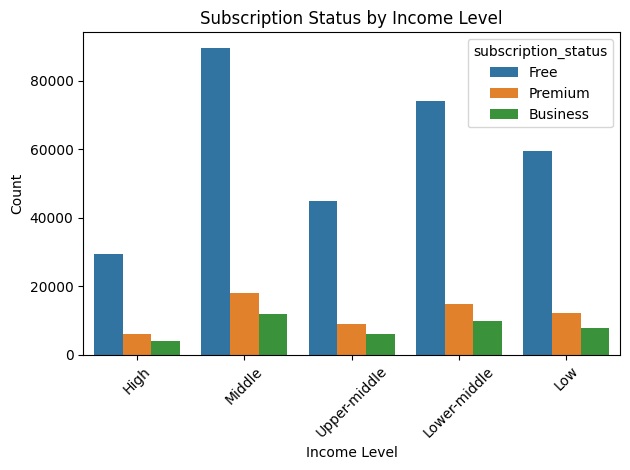

In [ ]:
sns.countplot(
    data=df,
    x='income_level',
    hue='subscription_status'
)

plt.title('Subscription Status by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

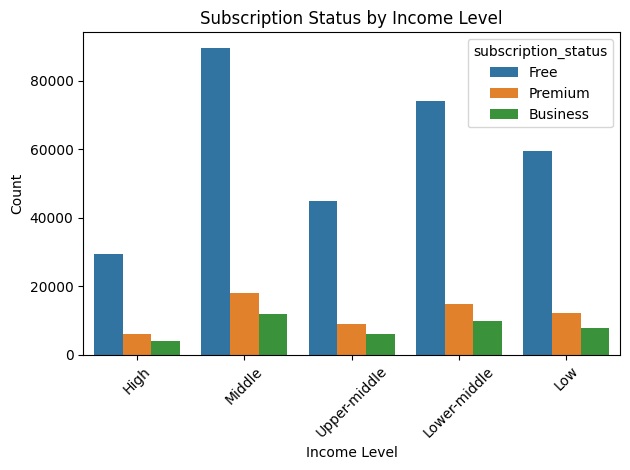

In [ ]:
sns.countplot(
    data=df,
    x='income_level',
    hue='subscription_status'
)

plt.title('Subscription Status by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

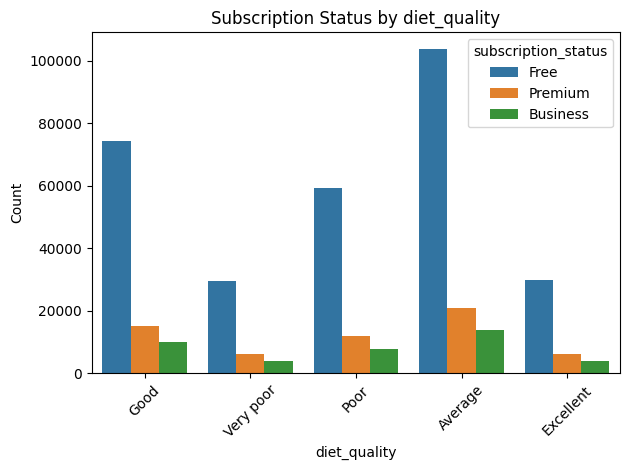

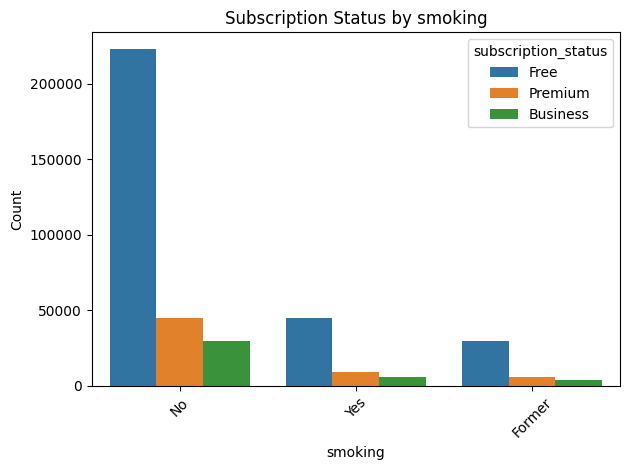

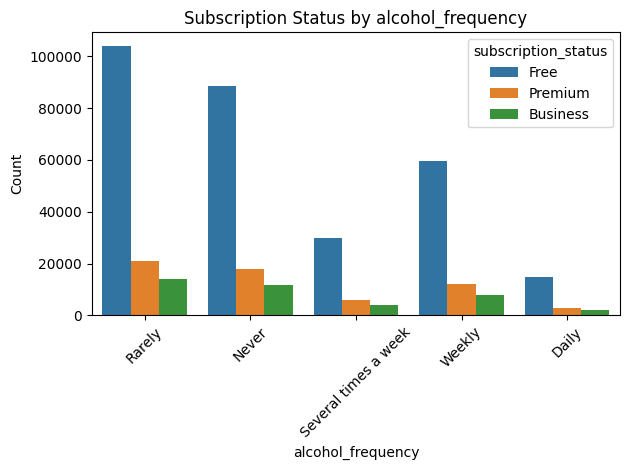

In [ ]:
lifestyle_vars = [
    'diet_quality',
    'smoking',
    'alcohol_frequency'
]

for var in lifestyle_vars:
    plt.figure()

    sns.countplot(
        data=df,
        x=var,
        hue='subscription_status'
    )

    plt.title(f'Subscription Status by {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

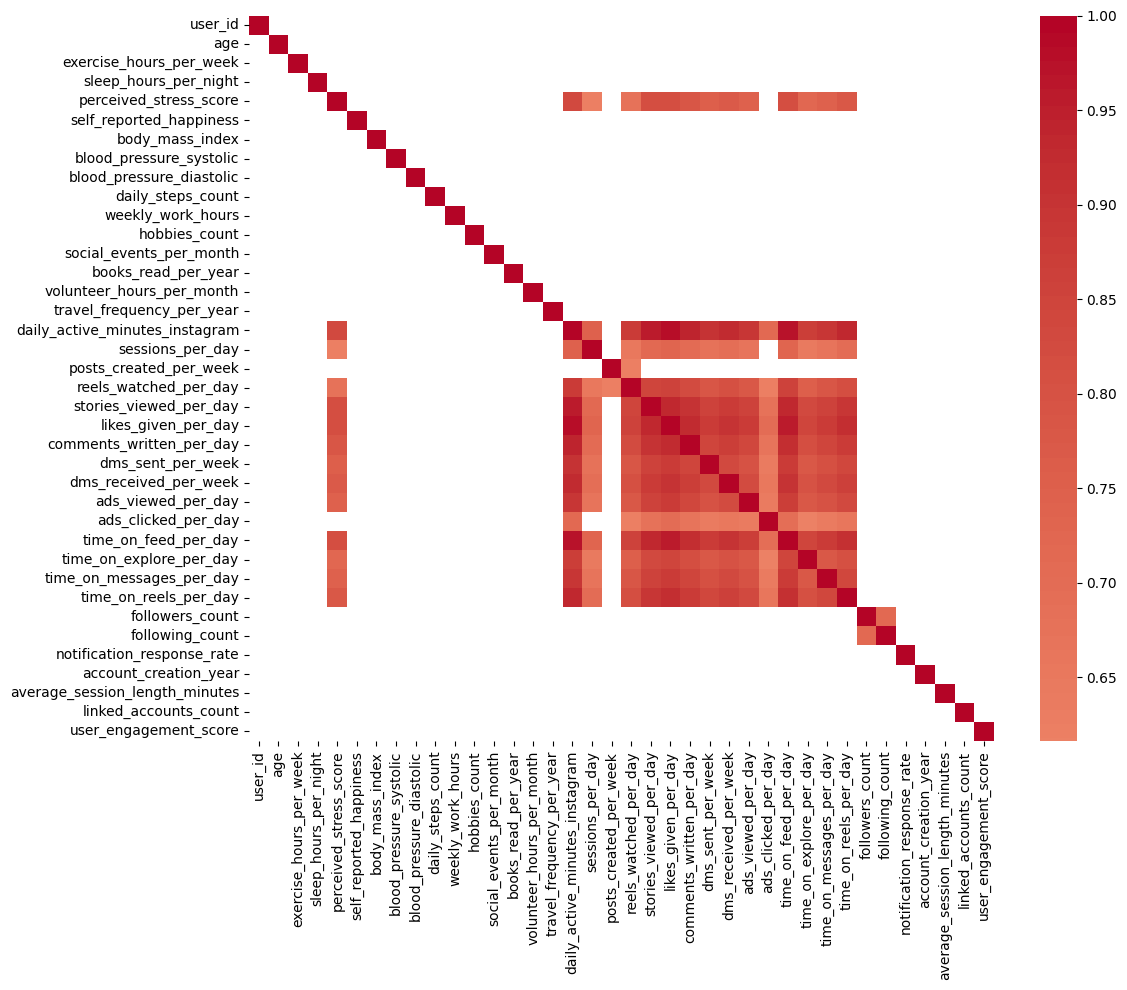

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

corr_filtered = corr[(corr > 0.6) | (corr < -0.6)]

plt.figure(figsize=(12,10))
sns.heatmap(corr_filtered, cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

In [ ]:
engagement_vars = [
    'sessions_per_day',
    'posts_created_per_week',
    'reels_watched_per_day',
    'stories_viewed_per_day',
    'likes_given_per_day',
    'comments_written_per_day',
    'dms_sent_per_week',
    'dms_received_per_week',
    'ads_viewed_per_day',
    'ads_clicked_per_day',
    'time_on_feed_per_day',
    'time_on_explore_per_day',
    'time_on_messages_per_day',
    'time_on_reels_per_day'
]

X = df[engagement_vars]
y = df['perceived_stress_score']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
model.score(X_test,y_test)

0.7069530638911998

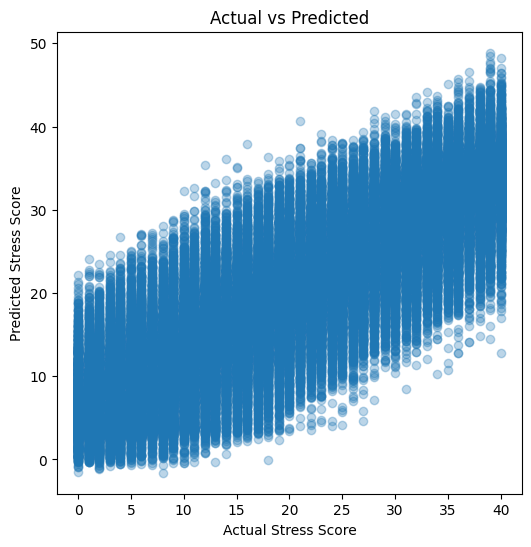

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Stress Score")
plt.ylabel("Predicted Stress Score")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_})

coefficients.sort_values(by='coefficient', ascending=False)

,feature,coefficient
3,stories_viewed_per_day,0.099143
5,comments_written_per_day,0.054088
4,likes_given_per_day,0.046264
9,ads_clicked_per_day,0.046103
8,ads_viewed_per_day,0.045795
7,dms_received_per_week,0.042378
6,dms_sent_per_week,0.036384
10,time_on_feed_per_day,0.034884
12,time_on_messages_per_day,0.023150
0,sessions_per_day,0.020907



This model estimates how stressed someone is based on specific types of engagement behavior — but not all engagement behaviors impact stress linearily.

- It has learned that stress levels tend to increase most with:

- Viewing more stories per day

- Writing more comments

- Giving more likes

- Clicking and viewing more ads

- Sending and receiving more DMs

- Spending more time on the feed

- Having more daily sessions

These behaviors are positively associated with higher stress.

- In contrast, some behaviors are slightly associated with lower stress:

- Creating more posts per week

- Watching more reels per day


Passive consumption and reactive behavior (scrolling, liking, commenting, viewing stories, ad interaction) are more strongly linked to higher stress.

Content creation (posting) and certain viewing behaviors (reels) show a small negative relationship with stress.